In [16]:
# Cell 1: Cài thư viện
!pip install ultralytics -q

In [17]:
from ultralytics import YOLO
import os, yaml, shutil

# ============================================================
# CẤU HÌNH - sửa MODEL_PATH theo đường dẫn thực tế
# ============================================================
MODEL_PATH   = "/kaggle/input/datasets/ankizsem/yolov8mai/best_yolov8m.pt"
DATASET_ROOT = "/kaggle/input/datasets/giahuy038/doanai/Final"
IMAGES_DIR   = os.path.join(DATASET_ROOT, "images")
TEST_LIST    = os.path.join(DATASET_ROOT, "split_dataset/test_files.txt")
CLASSES_FILE = os.path.join(DATASET_ROOT, "classes_en.txt")
LABELS_DIR   = os.path.join(DATASET_ROOT, "labels")

In [18]:
# ============================================================
# 1. Load model
# ============================================================
model = YOLO(MODEL_PATH)
print(f"✅ Model loaded | Classes: {model.names}")

✅ Model loaded | Classes: {0: 'Pedestrian Crossing', 1: 'Equal-level Intersection', 2: 'No Entry', 3: 'Right Turn Only', 4: 'Intersection', 5: 'Intersection with a non-priority road', 6: 'Danger zone on the left', 7: 'No Left Turn', 8: 'Bus Stop', 9: 'Roundabout', 10: 'No Stopping and No Parking', 11: 'U-Turn Allowed', 12: 'Lane Allocation', 13: 'Slow Down', 14: 'No Trucks Allowed', 15: 'Narrow Road on the Right', 16: 'Height Limit', 17: 'No U-Turn', 18: 'No Passenger Cars and Trucks', 19: 'No U-Turn and No Right Turn', 20: 'No Cars Allowed', 21: 'Narrow Road on the Left', 22: 'Uneven Road', 23: 'No Two or Three-wheeled Vehicles', 24: 'Customs Checkpoint', 25: 'Motorcycles Only', 26: 'Obstacle on the Road', 27: 'Children Present', 28: 'Trucks and Containers', 29: 'No Motorcycles Allowed', 30: 'Trucks Only', 31: 'Road with Surveillance Camera', 32: 'No Right Turn', 33: 'Double curve first to right', 34: 'No Containers Allowed', 35: 'No Left or Right Turn', 36: 'No Straight and Right Tur

In [19]:
# ============================================================
# 2. Đọc classes
# ============================================================
with open(CLASSES_FILE) as f:
    class_names = [l.strip() for l in f if l.strip()]
print(f"📋 {len(class_names)} classes: {class_names}")

📋 67 classes: ['Pedestrian Crossing', 'Equal-level Intersection', 'No Entry', 'Right Turn Only', 'Intersection', 'Intersection with a non-priority road', 'Danger zone on the left', 'No Left Turn', 'Bus Stop', 'Roundabout', 'No Stopping and No Parking', 'U-Turn Allowed', 'Lane Allocation', 'Slow Down', 'No Trucks Allowed', 'Narrow Road on the Right', 'Height Limit', 'No U-Turn', 'No Passenger Cars and Trucks', 'No U-Turn and No Right Turn', 'No Cars Allowed', 'Narrow Road on the Left', 'Uneven Road', 'No Two or Three-wheeled Vehicles', 'Customs Checkpoint', 'Motorcycles Only', 'Obstacle on the Road', 'Children Present', 'Trucks and Containers', 'No Motorcycles Allowed', 'Trucks Only', 'Road with Surveillance Camera', 'No Right Turn', 'Double curve first to right', 'No Containers Allowed', 'No Left or Right Turn', 'No Straight and Right Turn', 'Intersection with T-Junction', 'Speed limit (50km/h)', 'Speed limit (60km/h)', 'Speed limit (80km/h)', 'Speed limit (40km/h)', 'Left Turn', 'Low 

In [20]:
# ============================================================
# 3. Đọc danh sách ảnh test
# ============================================================
with open(TEST_LIST) as f:
    test_filenames = [l.strip() for l in f if l.strip()]

test_images, missing = [], []
for fname in test_filenames:
    full_path = os.path.join(IMAGES_DIR, fname)
    if os.path.exists(full_path):
        test_images.append(full_path)
    else:
        missing.append(fname)

print(f"📦 Tìm thấy: {len(test_images)}/{len(test_filenames)} ảnh")
if missing:
    print(f"⚠️  Thiếu {len(missing)} ảnh, ví dụ: {missing[:3]}")

📦 Tìm thấy: 677/677 ảnh


In [21]:
# ============================================================
# 4. Copy ảnh + label vào cấu trúc chuẩn YOLO
#    /kaggle/working/dataset/images/  ← ảnh
#    /kaggle/working/dataset/labels/  ← label (.txt)
#    YOLO tự map: đường dẫn ảnh → thay "images" → "labels"
# ============================================================
WORK_IMG_DIR = "/kaggle/working/dataset/images"
WORK_LBL_DIR = "/kaggle/working/dataset/labels"
os.makedirs(WORK_IMG_DIR, exist_ok=True)
os.makedirs(WORK_LBL_DIR, exist_ok=True)

copied, no_label = 0, []
for fname in test_filenames:
    img_src = os.path.join(IMAGES_DIR, fname)
    lbl_name = os.path.splitext(fname)[0] + ".txt"
    lbl_src  = os.path.join(LABELS_DIR, lbl_name)

    if not os.path.exists(img_src):
        continue

    shutil.copy2(img_src, os.path.join(WORK_IMG_DIR, fname))

    if os.path.exists(lbl_src):
        shutil.copy2(lbl_src, os.path.join(WORK_LBL_DIR, lbl_name))
        copied += 1
    else:
        no_label.append(fname)

print(f"✅ Đã copy {copied} cặp ảnh+label")
if no_label:
    print(f"⚠️  {len(no_label)} ảnh không có label: {no_label[:3]}")

# Kiểm tra nội dung label mẫu
sample_lbl_files = os.listdir(WORK_LBL_DIR)
if sample_lbl_files:
    with open(os.path.join(WORK_LBL_DIR, sample_lbl_files[0])) as f:
        content = f.read(200)
    print(f"\nLabel mẫu ({sample_lbl_files[0]}):\n{content}")

✅ Đã copy 677 cặp ảnh+label

Label mẫu (FisheyeCamera_1_00311_png.rf.b0abeeb32df8e582d0584c01e8a3e5d8.txt):
63 0.16706730769230768 0.5216346153846154 0.01201923076923077 0.020432692307692308
53 0.4230769230769231 0.5252403846153846 0.008413461538461538 0.02283653846153846
52 0.7860576923076923 0.44471153846


In [22]:
# ============================================================
# 5. Tạo data.yaml chuẩn
# ============================================================
data_yaml = {
    "path": "/kaggle/working/dataset",
    "train": "images",   # placeholder, không dùng
    "val":   "images",   # placeholder, không dùng
    "test":  "images",   # YOLO scan toàn bộ thư mục images/
    "nc":    len(class_names),
    "names": class_names,
}

yaml_path = "/kaggle/working/data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, allow_unicode=True)

print(f"\n✅ data.yaml tạo xong ({len(class_names)} classes)")


✅ data.yaml tạo xong (67 classes)


In [23]:
results = model.val(
    data      = yaml_path,
    split     = "test",
    imgsz     = 640,
    batch     = 16,
    conf      = 0.25,
    iou       = 0.5,
    device    = 0,
    plots     = True,
    verbose   = False,
    project   = "/kaggle/working/eval",
    name      = "test_final",   # ← đổi tên để không đọc cache cũ
    save_json = False,
)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,878,553 parameters, 0 gradients, 78.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1298.6±1121.7 MB/s, size: 82.9 KB)
val: Scanning /kaggle/working/dataset/labels... 677 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 677/677 1.2Kit/s 0.6s0.1ss
val: New cache created: /kaggle/working/dataset/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 43/43 2.4it/s 18.0s0.5s
                   all        677       1262      0.973      0.984      0.981      0.798
Speed: 0.8ms preprocess, 20.9ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/eval/test_final-2


In [24]:
# ============================================================
# 7. In kết quả
# ============================================================
print("\n========== KẾT QUẢ ĐÁNH GIÁ ==========")
print(f"mAP@0.5      : {results.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {results.box.map:.4f}")
print(f"Precision    : {results.box.mp:.4f}")
print(f"Recall       : {results.box.mr:.4f}")

print("\n--- Per-class AP@0.5 ---")
for i, name in enumerate(class_names):
    ap = results.box.ap50[i] if i < len(results.box.ap50) else float('nan')
    print(f"  {name:30s}: {ap:.4f}")

print(f"\n📁 Plots lưu tại: /kaggle/working/eval/test_run/")


========== KẾT QUẢ ĐÁNH GIÁ ==========
mAP@0.5      : 0.9806
mAP@0.5:0.95 : 0.7982
Precision    : 0.9735
Recall       : 0.9840

--- Per-class AP@0.5 ---
  Pedestrian Crossing           : 0.9903
  Equal-level Intersection      : 0.9950
  No Entry                      : 0.9942
  Right Turn Only               : 0.9750
  Intersection                  : 0.9950
  Intersection with a non-priority road: 0.9250
  Danger zone on the left       : 0.9950
  No Left Turn                  : 0.9950
  Bus Stop                      : 0.9950
  Roundabout                    : 0.9950
  No Stopping and No Parking    : 0.9950
  U-Turn Allowed                : 0.9950
  Lane Allocation               : 0.9950
  Slow Down                     : 0.9950
  No Trucks Allowed             : 0.9950
  Narrow Road on the Right      : 0.9950
  Height Limit                  : 0.8588
  No U-Turn                     : 0.9950
  No Passenger Cars and Trucks  : 0.9950
  No U-Turn and No Right Turn   : 0.9950
  No Cars Allowed  

In [1]:
import os
import shutil
from collections import defaultdict

DATASET_ROOT = "/kaggle/input/datasets/giahuy038/doanai/Final"
CLASSES_FILE = os.path.join(DATASET_ROOT, "classes_en.txt")
LABELS_DIR   = os.path.join(DATASET_ROOT, "labels")
SPLIT_DIR    = os.path.join(DATASET_ROOT, "split_dataset")

# Đọc class names
with open(CLASSES_FILE) as f:
    class_names = [l.strip() for l in f if l.strip()]

def count_class_stats(label_dir, file_list):
    img_count  = defaultdict(int)
    inst_count = defaultdict(int)
    found = 0
    for fname in file_list:
        base_name = os.path.splitext(fname)[0]
        lbl_name  = base_name + ".txt"
        lbl_path  = os.path.join(label_dir, lbl_name)
        if not os.path.exists(lbl_path):
            continue
        found += 1
        seen = set()
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                try:
                    cls_id = int(float(parts[0]))
                    inst_count[cls_id] += 1
                    seen.add(cls_id)
                except ValueError:
                    continue
        for cls_id in seen:
            img_count[cls_id] += 1
    return img_count, inst_count, found

# Đọc splits
splits = {}
for split in ["train", "valid", "test"]:
    list_file = os.path.join(SPLIT_DIR, f"{split}_files.txt")
    if os.path.exists(list_file):
        with open(list_file) as f:
            splits[split] = [l.strip() for l in f if l.strip()]
    else:
        splits[split] = []

# ── Thống kê tổng số file ────────────────────────────────────────────────────
print("📦 Số file trong mỗi split:")
for split, files in splits.items():
    label_name = "ảnh"
    print(f"   {split:5s}: {len(files)} {label_name}")

# ── Đếm stats ────────────────────────────────────────────────────────────────
stats = {}
for split, files in splits.items():
    img_c, inst_c, found = count_class_stats(LABELS_DIR, files)
    stats[split] = {"img": img_c, "inst": inst_c, "found": found}
    print(f"   {split:5s}: tìm được label của {found}/{len(files)} ảnh")

# ── Bảng chi tiết per-class ──────────────────────────────────────────────────
header = (
    f"\n{'ID':>4}  {'Class':<45}"
    f"{'Ảnh_train':>10} {'Inst_train':>11}"
    f"{'Ảnh_valid':>10} {'Inst_valid':>11}"
    f"{'Ảnh_test':>9} {'Inst_test':>10}"
    f"{'Tổng_inst':>11}"
)
print(header)
print("-" * 130)

for i, name in enumerate(class_names):
    tr_img  = stats["train"]["img"].get(i, 0)
    tr_inst = stats["train"]["inst"].get(i, 0)
    vl_img  = stats["valid"]["img"].get(i, 0)
    vl_inst = stats["valid"]["inst"].get(i, 0)
    te_img  = stats["test"]["img"].get(i, 0)
    te_inst = stats["test"]["inst"].get(i, 0)
    total   = tr_inst + vl_inst + te_inst

    if tr_img > 0 or vl_img > 0 or te_img > 0:
        print(
            f"{i:>4}  {name:<45}"
            f"{tr_img:>10} {tr_inst:>11}"
            f"{vl_img:>10} {vl_inst:>11}"
            f"{te_img:>9} {te_inst:>10}"
            f"{total:>11}"
        )

# ── Tổng kết ─────────────────────────────────────────────────────────────────
print("=" * 130)

for split in ["train", "valid", "test"]:
    total_inst    = sum(stats[split]["inst"].values())
    active_classes = sum(1 for i in range(len(class_names)) if stats[split]["img"].get(i, 0) > 0)
    print(f"📊 {split:5s}: {active_classes}/{len(class_names)} classes có ảnh | {total_inst} tổng instances")

📦 Số file trong mỗi split:
   train: 5391 ảnh
   valid: 678 ảnh
   test : 677 ảnh
   train: tìm được label của 5391/5391 ảnh
   valid: tìm được label của 678/678 ảnh
   test : tìm được label của 677/677 ảnh

  ID  Class                                         Ảnh_train  Inst_train Ảnh_valid  Inst_valid Ảnh_test  Inst_test  Tổng_inst
----------------------------------------------------------------------------------------------------------------------------------
   0  Pedestrian Crossing                                 255         255        22          22       35         35        312
   1  Equal-level Intersection                             15          15         1           1        6          6         22
   2  No Entry                                            361         363        58          58       48         49        470
   3  Right Turn Only                                     349         349        57          57       48         48        454
   4  Intersection        

In [35]:
# ============================================================
# BƯỚC 2: Per-class AP từ results.box (chuẩn YOLO)
# ============================================================
import pandas as pd
rows = []
for i, name in enumerate(class_names):
    if i >= len(results.box.ap50):
        continue
    ap50 = float(results.box.ap50[i])
    p    = float(results.box.p[i])  if i < len(results.box.p)  else float('nan')
    r    = float(results.box.r[i])  if i < len(results.box.r)  else float('nan')
    rows.append({
        "ID"      : i,
        "Class"   : name,
        "P (%)"   : round(p   * 100, 1),
        "R (%)"   : round(r   * 100, 1),
        "AP@0.5"  : round(ap50 * 100, 1),
    })
 
df = pd.DataFrame(rows).sort_values("AP@0.5", ascending=True)
 
# ── In bảng per-class ────────────────────────────────────────
print("\n" + "="*75)
print("  📊 PER-CLASS: Precision / Recall / AP@0.5")
print("="*75)
print(f"{'ID':>4}  {'Class':<40} {'P':>7} {'R':>7} {'AP@0.5':>8}")
print("-"*75)
for _, row in df.iterrows():
    ap = row["AP@0.5"]
    flag = " ⚠" if ap < 70 else ("  ✓" if ap >= 90 else "   ")
    print(f"{int(row['ID']):>4}  {row['Class']:<40} "
          f"{row['P (%)']:>6.1f}% {row['R (%)']:>6.1f}% "
          f"{ap:>7.1f}%{flag}")
 
# ── Tóm tắt ──────────────────────────────────────────────────
bad  = df[df["AP@0.5"] <  70]
mid  = df[(df["AP@0.5"] >= 70) & (df["AP@0.5"] < 90)]
good = df[df["AP@0.5"] >= 90]
 
print("="*75)
print(f"\n  ✅ Tốt  (≥90%): {len(good)} classes")
print(f"  🔶 Trung bình (70–90%): {len(mid)} classes")
print(f"  ❌ Kém  (<70%): {len(bad)} classes")
if len(bad) > 0:
    print(f"\n  ❌ Classes cần cải thiện:")
    for _, r in bad.iterrows():
        print(f"     Class {int(r['ID']):2d} | {r['Class']:<40} "
              f"| P:{r['P (%)']:>5.1f}% R:{r['R (%)']:>5.1f}% AP:{r['AP@0.5']:>5.1f}%")


  📊 PER-CLASS: Precision / Recall / AP@0.5
  ID  Class                                          P       R   AP@0.5
---------------------------------------------------------------------------
  56  Speed Limit 110                           100.0%   85.7%    85.5%   
  16  Height Limit                               87.5%   87.5%    85.9%   
  53  Red Light                                  85.6%   86.4%    86.3%   
  26  Obstacle on the Road                       85.7%  100.0%    87.6%   
   5  Intersection with a non-priority road     100.0%   91.1%    92.5%  ✓
  45  One-way street                            100.0%   94.7%    94.5%  ✓
  61  Speed Limit 50                             97.6%   95.7%    95.5%  ✓
  60  Speed Limit 40                             92.8%   92.3%    96.2%  ✓
  41  Speed limit (40km/h)                       97.0%   97.0%    96.4%  ✓
  57  Speed Limit 120                            96.8%   96.8%    96.4%  ✓
  66  Stop                                       96.9%   9


Vẽ confusion matrix: 67 classes có GT > 0


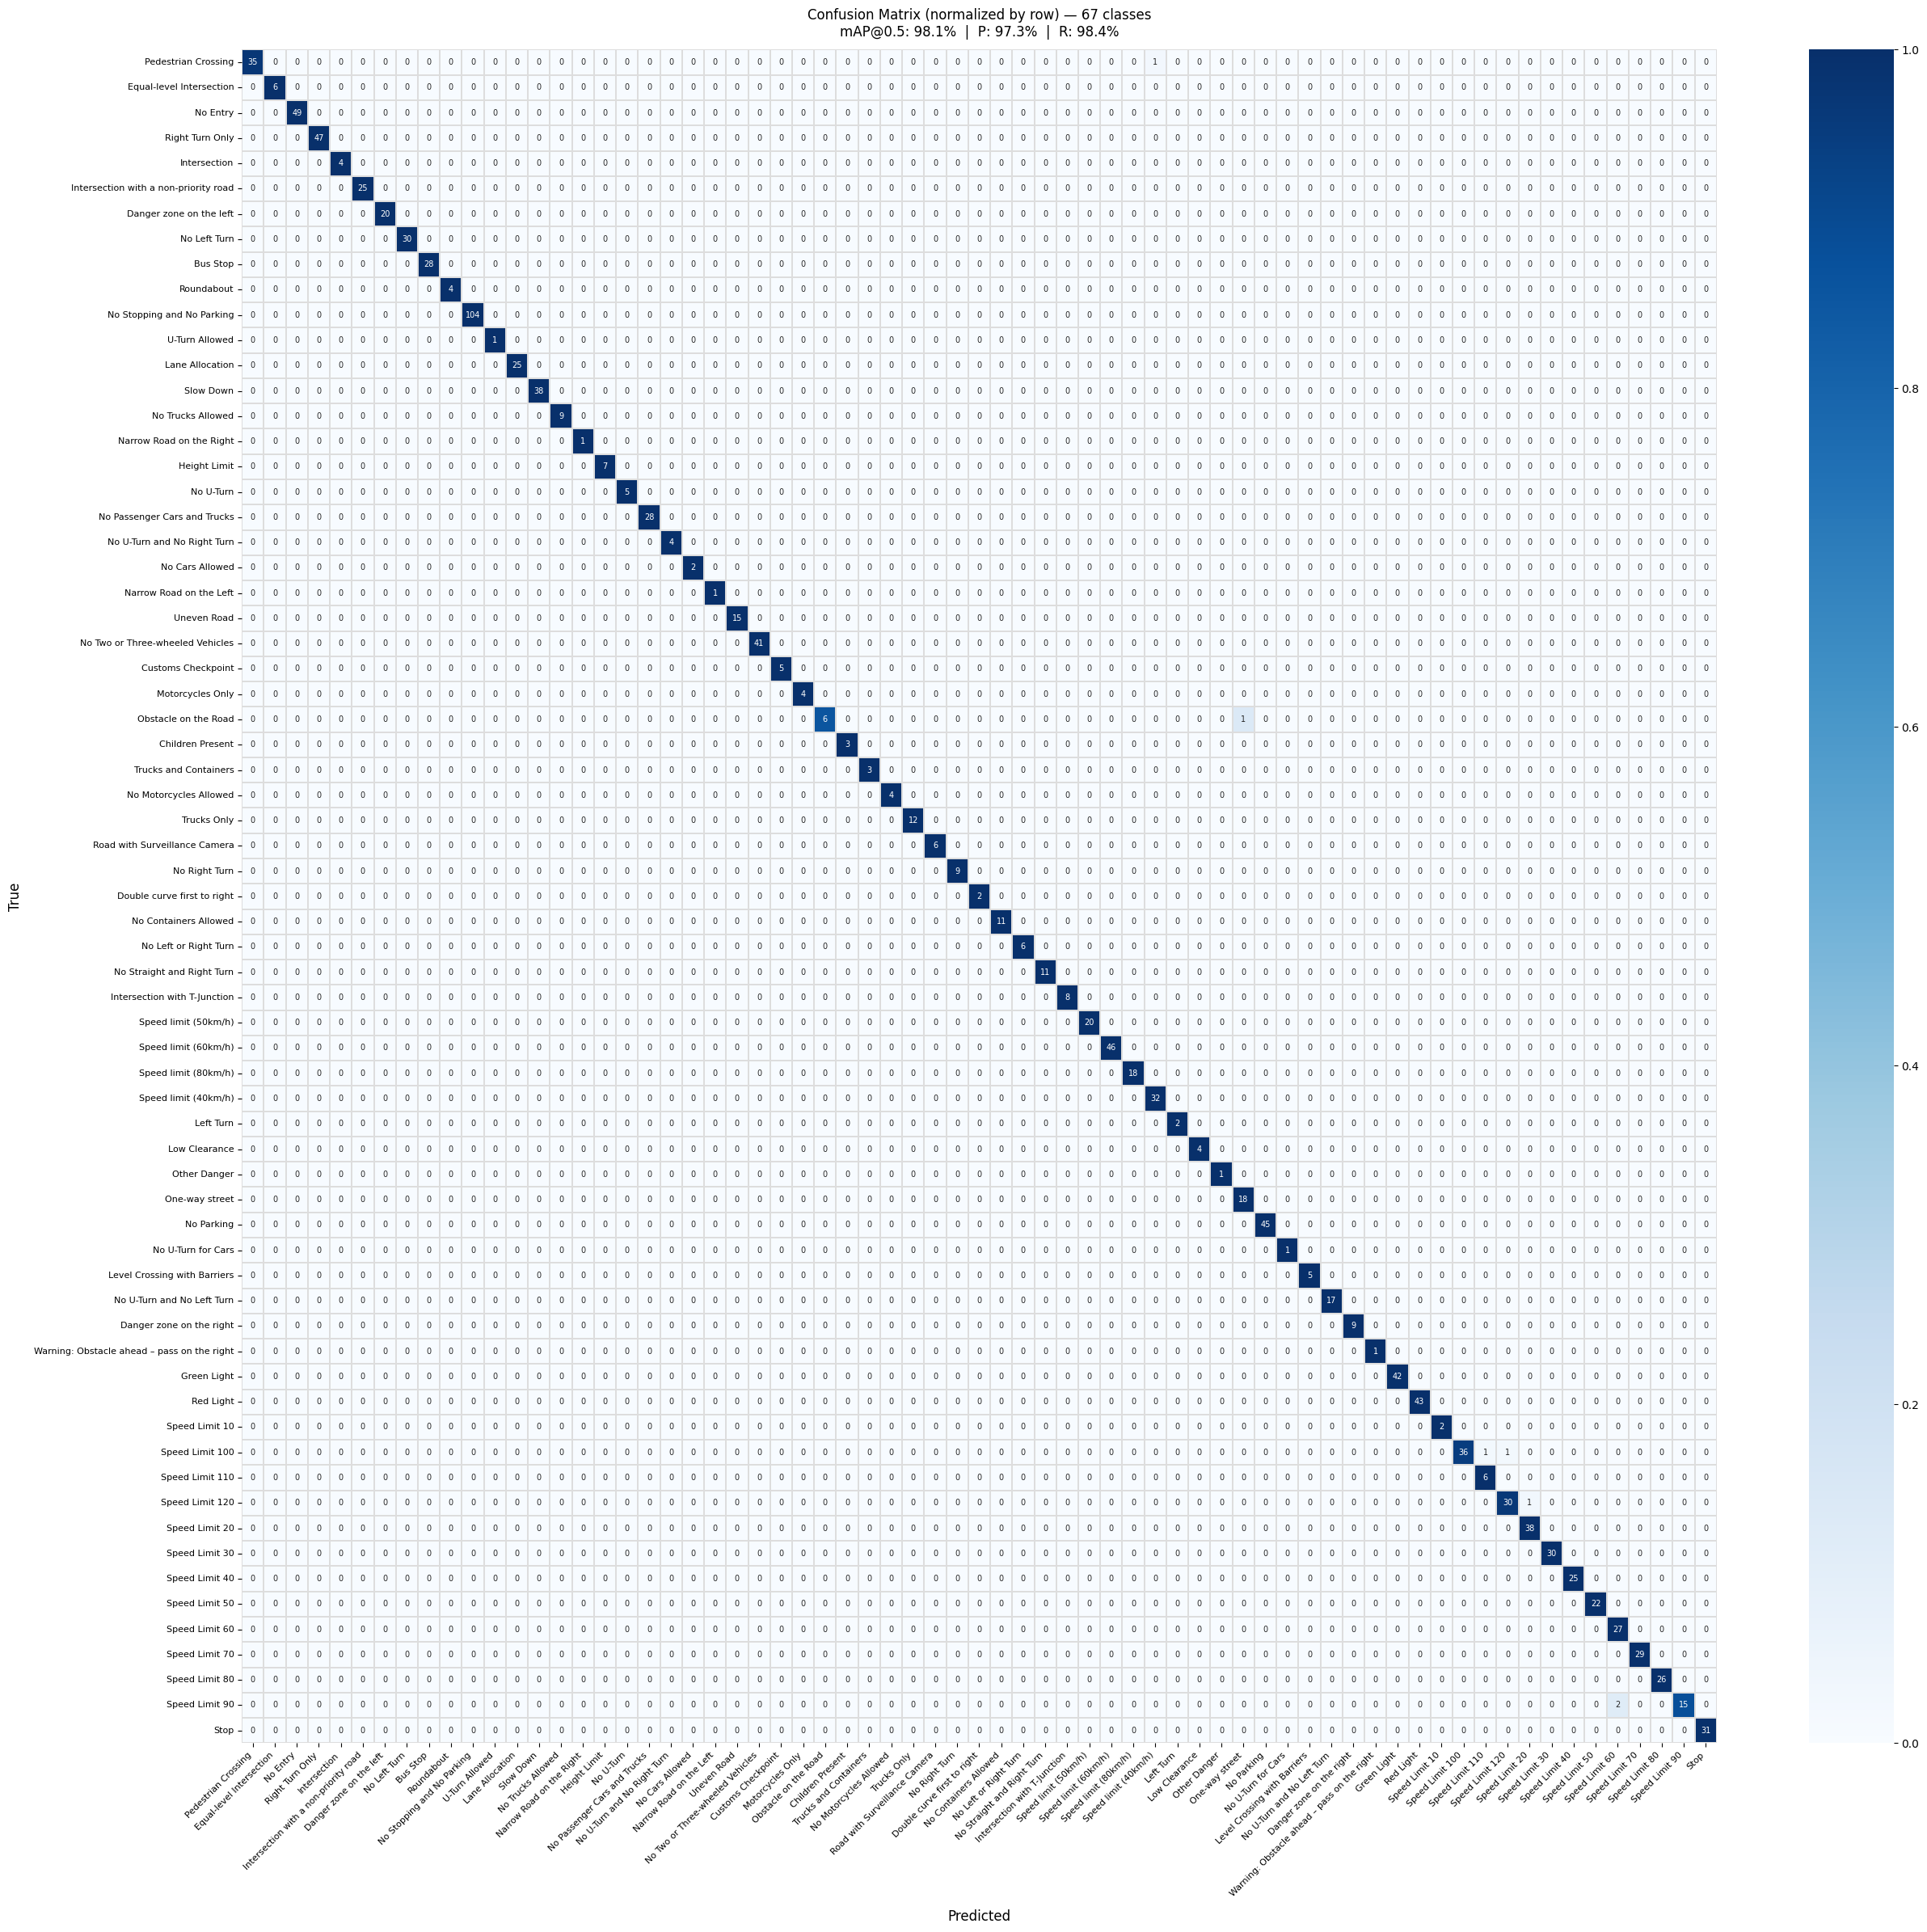

✅ Confusion matrix lưu tại: /kaggle/working/confusion_matrix_fixed.png


In [36]:
# ============================================================
# BƯỚC 3: Confusion matrix từ results (YOLO tính sẵn)
# ============================================================
# YOLO lưu confusion matrix tại results.confusion_matrix.matrix
cm_raw = results.confusion_matrix.matrix  # shape: (nc+1, nc+1) bao gồm background
 
# Bỏ hàng/cột background (index cuối)
nc = len(class_names)
cm = cm_raw[:nc, :nc].astype(int)
 
# Normalize theo hàng (true class)
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm.astype(float), row_sum,
                    out=np.zeros_like(cm, dtype=float),
                    where=row_sum != 0)
 
# Chỉ lấy các class có GT > 0 để tránh hàng trống
has_gt   = row_sum.flatten() > 0
cls_idx  = [i for i in range(nc) if has_gt[i]]
cls_lbls = [class_names[i] for i in cls_idx]
 
cm_show      = cm[np.ix_(cls_idx, cls_idx)]
cm_norm_show = cm_norm[np.ix_(cls_idx, cls_idx)]
 
print(f"\nVẽ confusion matrix: {len(cls_idx)} classes có GT > 0")
 
fig, ax = plt.subplots(figsize=(26, 24), facecolor="white")
sns.heatmap(
    cm_norm_show,
    annot=cm_show,
    fmt="d",
    xticklabels=cls_lbls,
    yticklabels=cls_lbls,
    cmap="Blues",
    ax=ax,
    annot_kws={"size": 7},
    vmin=0, vmax=1,
    linewidths=0.3,
    linecolor="#dddddd",
)
ax.set_xlabel("Predicted", fontsize=12, labelpad=10)
ax.set_ylabel("True",      fontsize=12, labelpad=10)
ax.set_title(
    f"Confusion Matrix (normalized by row) — {len(cls_idx)} classes\n"
    f"mAP@0.5: {results.box.map50*100:.1f}%  |  "
    f"P: {results.box.mp*100:.1f}%  |  R: {results.box.mr*100:.1f}%",
    fontsize=12, pad=12
)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_fixed.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix lưu tại: /kaggle/working/confusion_matrix_fixed.png")

/tmp/ipykernel_57/3818542510.py:64: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/3818542510.py:64: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/3818542510.py:64: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/3818542510.py:65: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/perclass_analysis_fixed.png",
/tmp/ipykernel_57/3818542510.py:65: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/perclass_analysis_fixed.png",
/tmp/ipykernel_57/3818542510.py:65: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/perclass_analysis_fixed.png",
/usr/local/lib/python3.12/dist

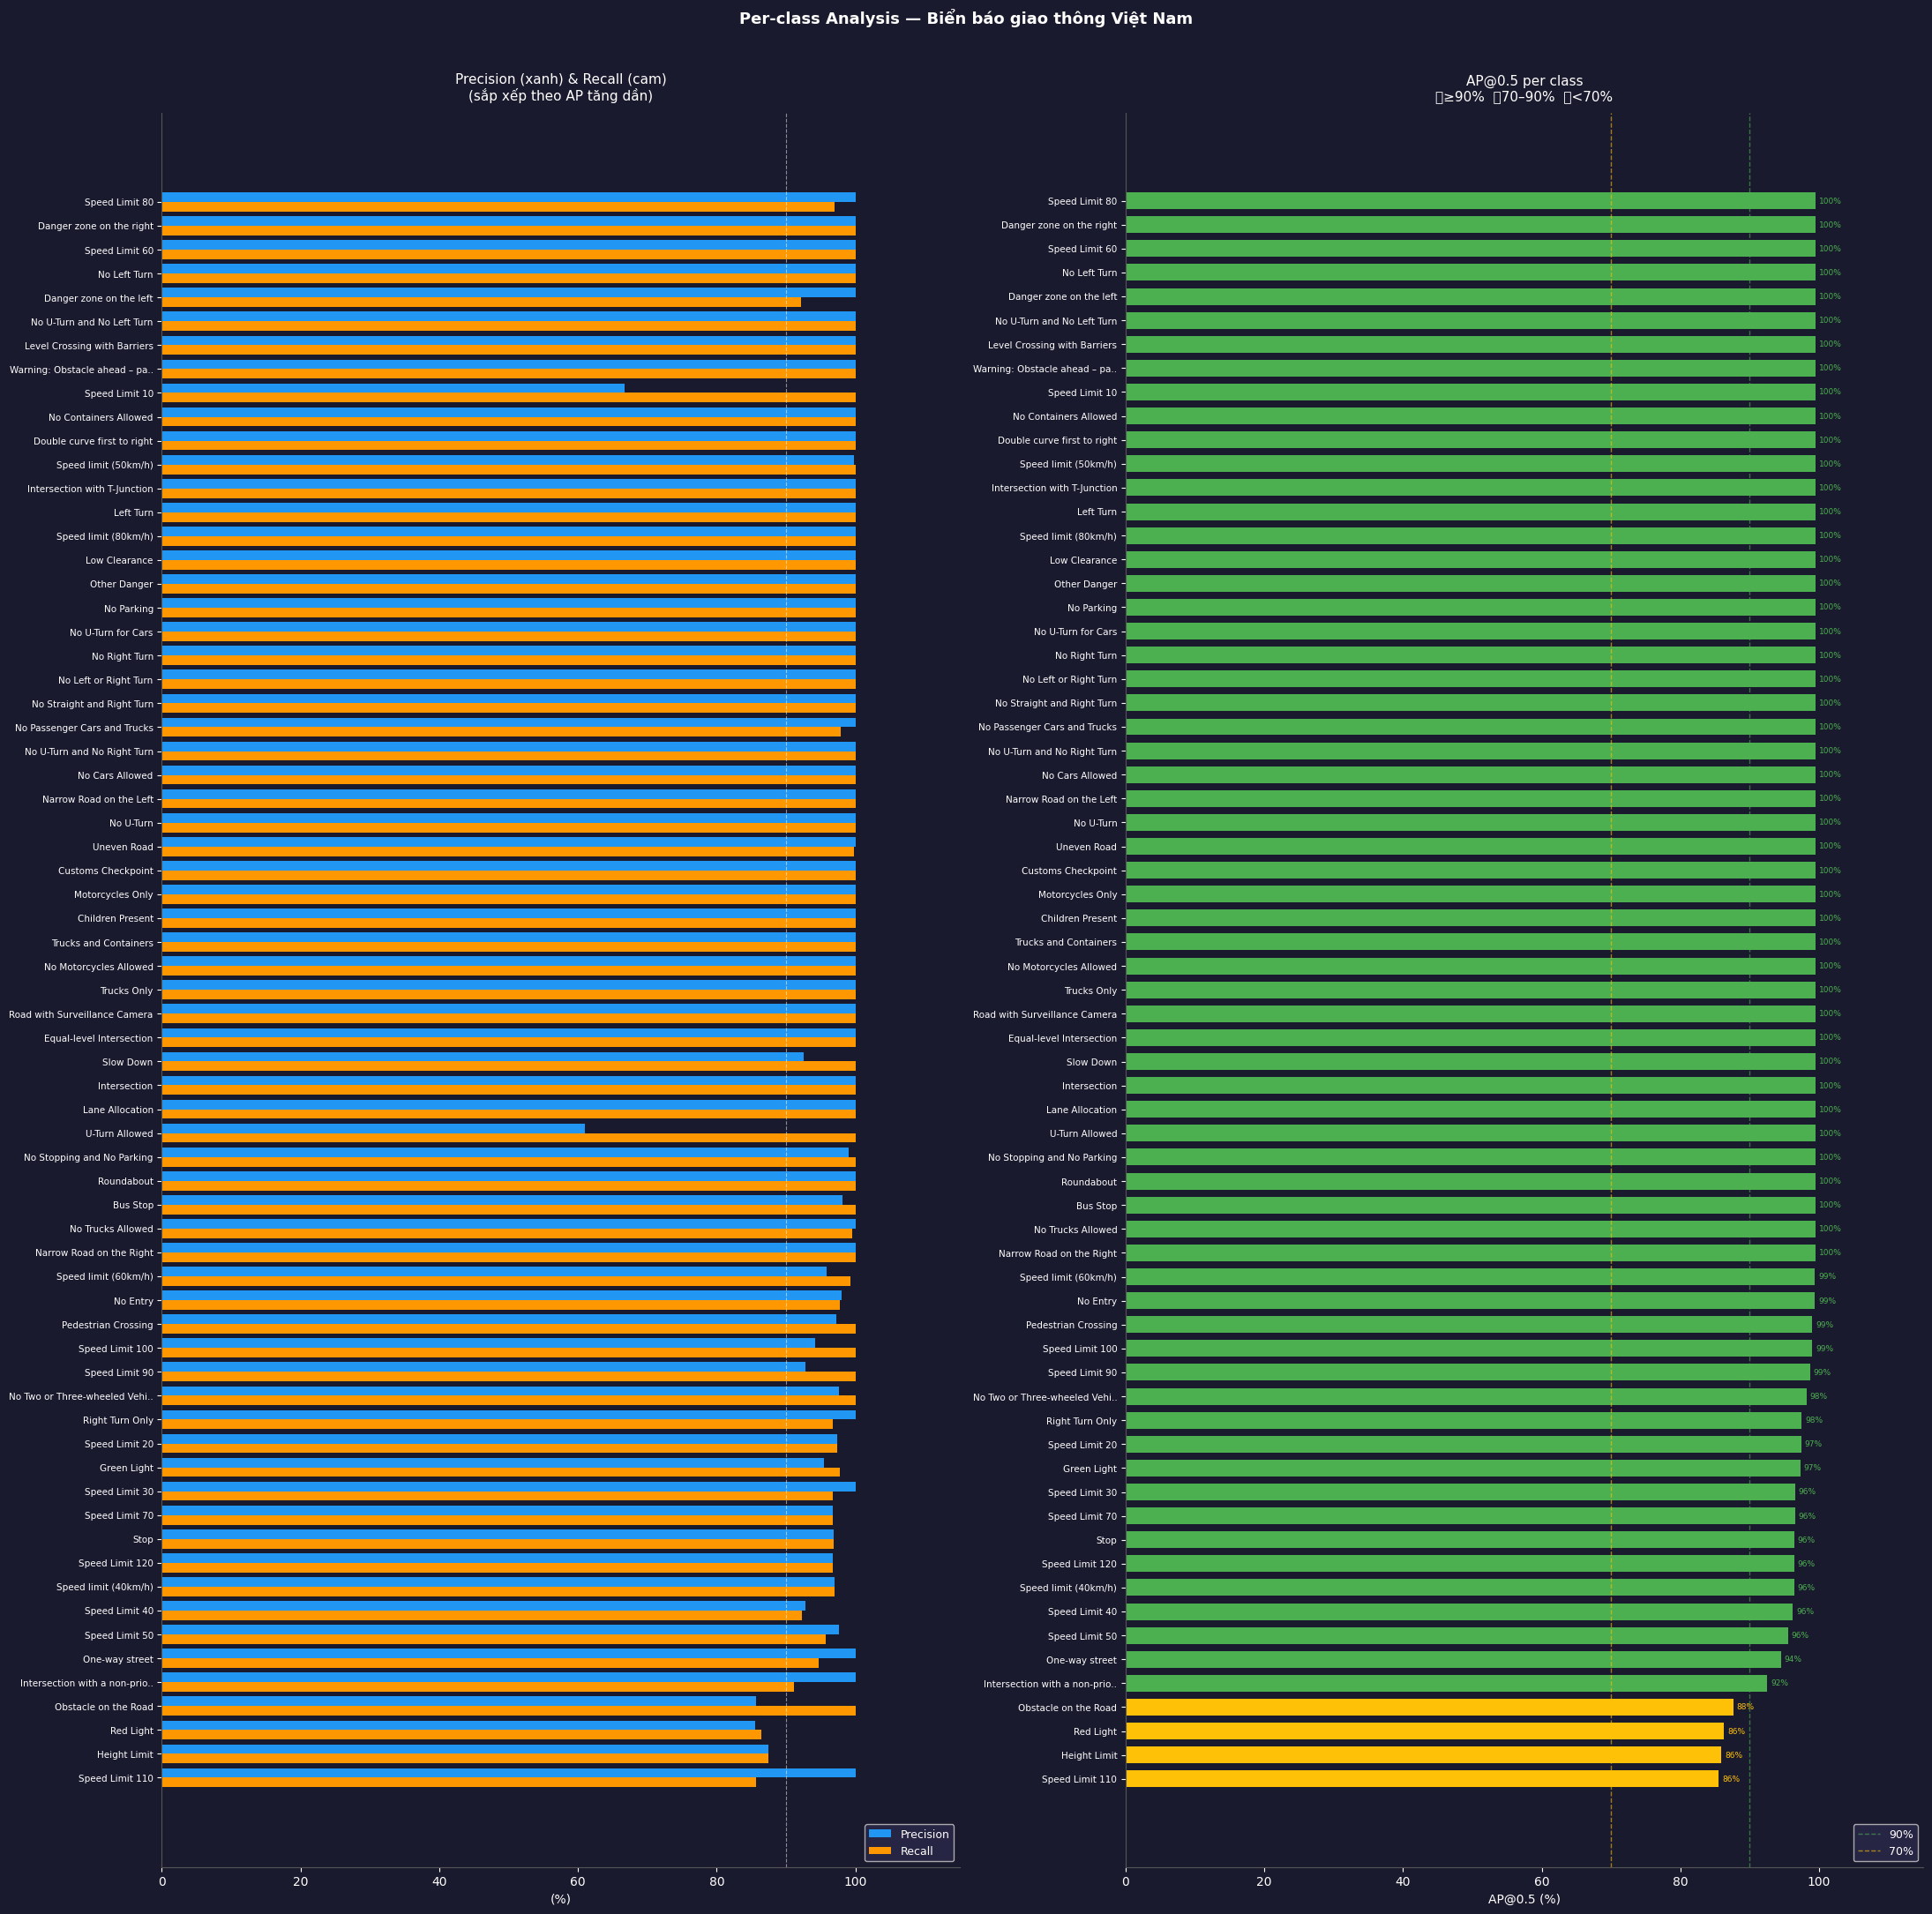

✅ Per-class chart lưu tại: /kaggle/working/perclass_analysis_fixed.png


In [37]:
# ============================================================
# BƯỚC 4: Bar chart AP@0.5 per class (2 panel)
# ============================================================
fig, axes = plt.subplots(1, 2,
                          figsize=(22, max(8, len(df) * 0.32)),
                          facecolor="#1a1a2e")
 
short_names = [n[:28] + ".." if len(n) > 30 else n for n in df["Class"].tolist()]
y_pos = list(range(len(df)))
 
# Panel trái: P và R stacked
ax1 = axes[0]
ax1.set_facecolor("#1a1a2e")
ax1.barh(y_pos, df["P (%)"], color="#2196F3", label="Precision", height=0.4,
         align="edge")
ax1.barh([y - 0.4 for y in y_pos], df["R (%)"], color="#FF9800",
         label="Recall", height=0.4, align="edge")
ax1.axvline(x=90, color="white", linestyle="--", linewidth=0.8, alpha=0.5)
ax1.set_xlim(0, 115)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(short_names, fontsize=7.5, color="white")
ax1.set_xlabel("(%)", color="white", fontsize=10)
ax1.set_title("Precision (xanh) & Recall (cam)\n(sắp xếp theo AP tăng dần)",
              color="white", fontsize=11, pad=10)
ax1.tick_params(colors="white")
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
for spine in ["bottom", "left"]:
    ax1.spines[spine].set_color("#555")
ax1.legend(loc="lower right", fontsize=9,
           facecolor="#2a2a4a", labelcolor="white")
 
# Panel phải: AP@0.5
ax2 = axes[1]
ax2.set_facecolor("#1a1a2e")
colors = ["#4CAF50" if a >= 90 else ("#FFC107" if a >= 70 else "#F44336")
          for a in df["AP@0.5"]]
ax2.barh(y_pos, df["AP@0.5"], color=colors, height=0.7)
ax2.axvline(x=90, color="#4CAF50", linestyle="--", linewidth=1, alpha=0.6, label="90%")
ax2.axvline(x=70, color="#FFC107", linestyle="--", linewidth=1, alpha=0.6, label="70%")
ax2.set_xlim(0, 115)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(short_names, fontsize=7.5, color="white")
ax2.set_xlabel("AP@0.5 (%)", color="white", fontsize=10)
ax2.set_title("AP@0.5 per class\n🟢≥90%  🟡70–90%  🔴<70%",
              color="white", fontsize=11, pad=10)
ax2.tick_params(colors="white")
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)
for spine in ["bottom", "left"]:
    ax2.spines[spine].set_color("#555")
ax2.legend(loc="lower right", fontsize=9,
           facecolor="#2a2a4a", labelcolor="white")
 
# Ghi số AP lên bar
for i, (_, r) in enumerate(df.iterrows()):
    ax2.text(r["AP@0.5"] + 0.5, i, f"{r['AP@0.5']:.0f}%",
             va="center", fontsize=6.5,
             color="#4CAF50" if r["AP@0.5"] >= 90
             else ("#FFC107" if r["AP@0.5"] >= 70 else "#F44336"))
 
fig.suptitle("Per-class Analysis — Biển báo giao thông Việt Nam",
             color="white", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/perclass_analysis_fixed.png",
            dpi=130, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("✅ Per-class chart lưu tại: /kaggle/working/perclass_analysis_fixed.png")